# Task 2: Customer Segmentation Using K-Means Clustering

## Objective
The objective of this project is to segment customers based on spending behavior and income level, then suggest marketing strategies for each group.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../images', exist_ok=True)

In [2]:
df = pd.read_csv('../data/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Overview

The dataset contains customer demographic and spending behavior information.  
Important columns include age, annual income, and spending score.

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

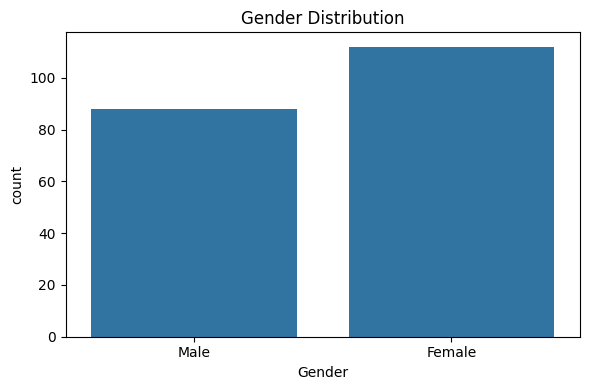

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.tight_layout()
plt.savefig('../images/gender_distribution.png')
plt.show()

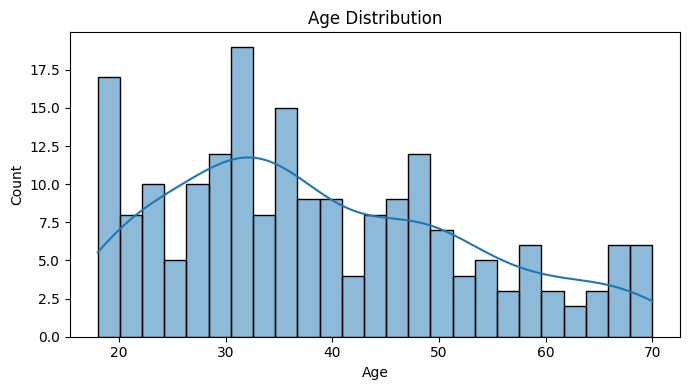

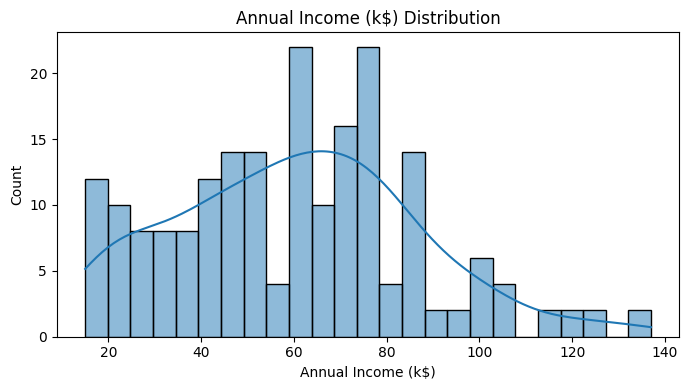

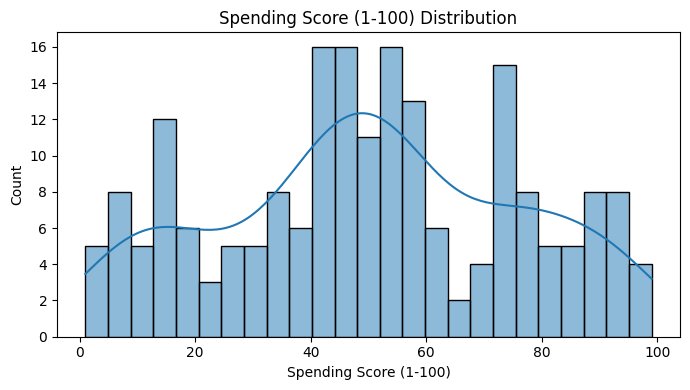

In [8]:
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=25)
    plt.title(f'{col} Distribution')
    plt.tight_layout()
    plt.savefig(f"../images/{col.replace(' ', '_').replace('(', '').replace(')', '').replace('$', 'dollar')}_distribution.png")
    plt.show()

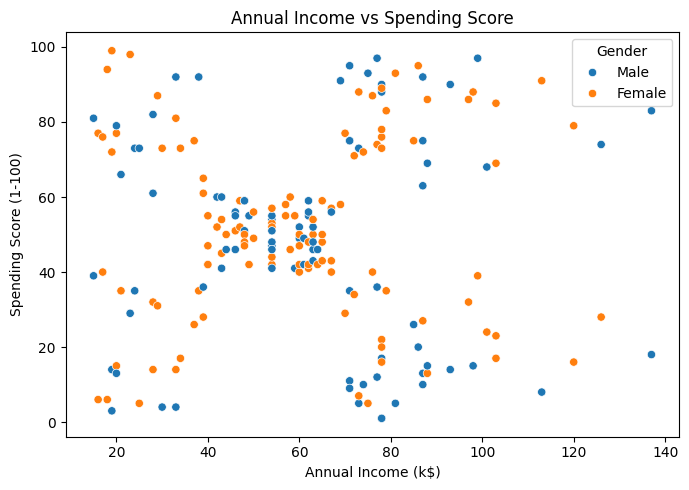

In [9]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender',
    data=df
)
plt.title('Annual Income vs Spending Score')
plt.tight_layout()
plt.savefig('../images/income_vs_spending_score.png')
plt.show()

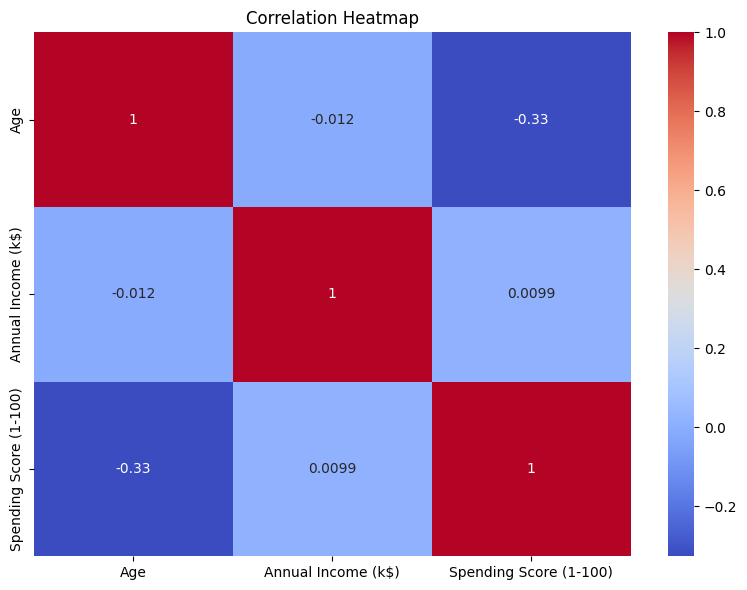

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png')
plt.show()

## Feature Selection

For customer segmentation, Annual Income and Spending Score were selected because they directly represent purchasing power and spending behavior.

In [11]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Finding Optimal Number of Clusters

The Elbow Method was used to identify a suitable number of clusters.

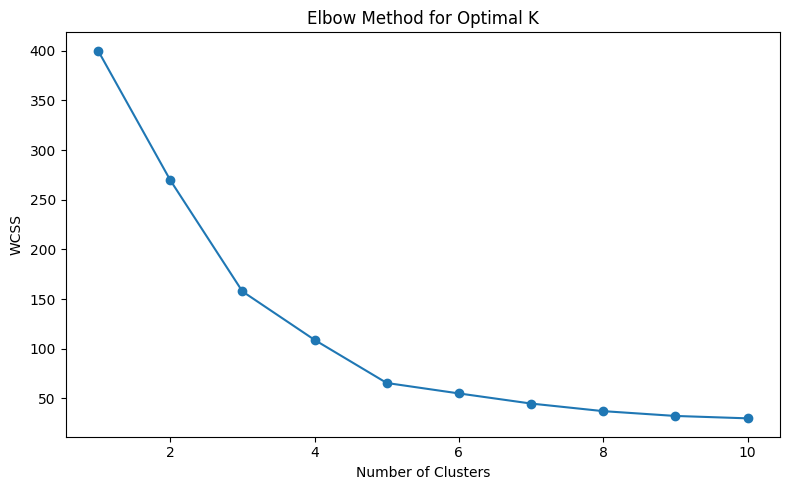

In [12]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.tight_layout()
plt.savefig('../images/elbow_method.png')
plt.show()

In [13]:
silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

silhouette_scores

{2: 0.3212707813918878,
 3: 0.46658474419000145,
 4: 0.4939069237513199,
 5: 0.5546571631111091,
 6: 0.5398800926790663,
 7: 0.5281492781108291,
 8: 0.4552147906587443,
 9: 0.4570853966942764,
 10: 0.4431713026508046}

Based on the Elbow Method, segmentation interpretability, and the silhouette scores, 5 clusters were selected. The silhouette score is highest at k=5, which supports the final choice.

In [14]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


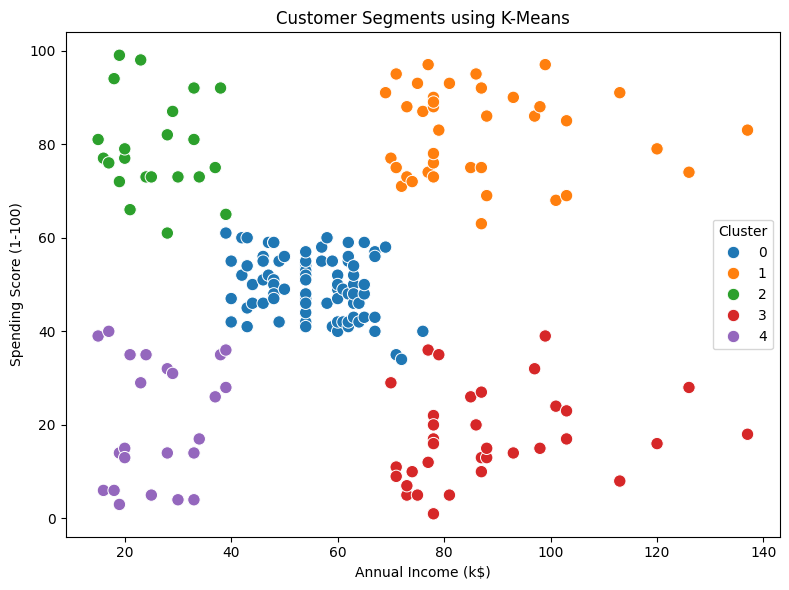

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='tab10',
    data=df,
    s=80
)

plt.title('Customer Segments using K-Means')
plt.tight_layout()
plt.savefig('../images/customer_segments_kmeans.png')
plt.show()

## PCA Visualization

PCA was applied to Age, Annual Income, and Spending Score only for visualization in two dimensions. The K-Means model itself was trained on Annual Income and Spending Score.

In [16]:
pca_features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

pca_scaled = scaler.fit_transform(pca_features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_scaled)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

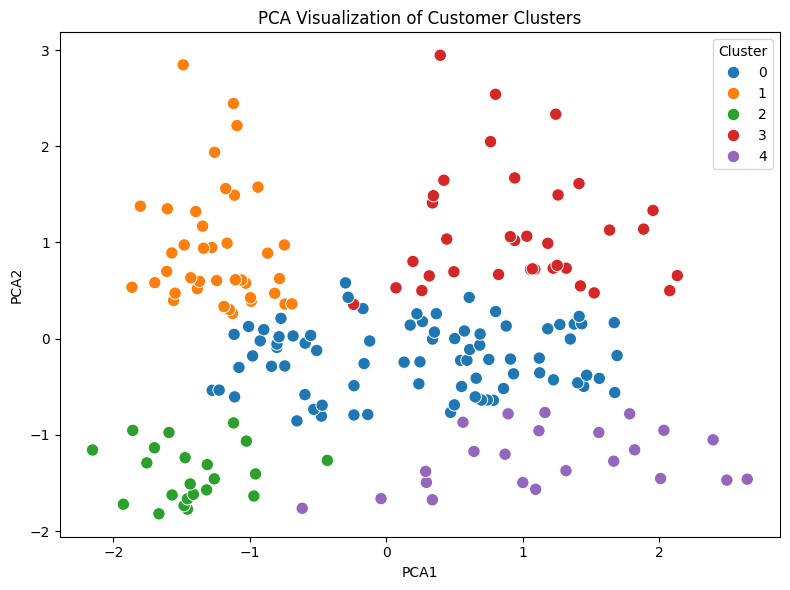

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='tab10',
    data=df,
    s=80
)

plt.title('PCA Visualization of Customer Clusters')
plt.tight_layout()
plt.savefig('../images/pca_cluster_visualization.png')
plt.show()

In [18]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


## Cluster Interpretation and Marketing Strategies

The clusters can be interpreted based on average annual income and spending score. The cluster summary output shows:

- **Cluster 0:** Average income and average spending customers.
- **Cluster 1:** High income and high spending customers.
- **Cluster 2:** Low income and high spending customers.
- **Cluster 3:** High income and low spending customers.
- **Cluster 4:** Low income and low spending customers.

In [19]:
for cluster in sorted(df['Cluster'].unique()):
    print(f"Cluster {cluster}")
    print(df[df['Cluster'] == cluster][['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean())
    print("-" * 50)

Cluster 0
Age                       42.716049
Annual Income (k$)        55.296296
Spending Score (1-100)    49.518519
dtype: float64
--------------------------------------------------
Cluster 1
Age                       32.692308
Annual Income (k$)        86.538462
Spending Score (1-100)    82.128205
dtype: float64
--------------------------------------------------
Cluster 2
Age                       25.272727
Annual Income (k$)        25.727273
Spending Score (1-100)    79.363636
dtype: float64
--------------------------------------------------
Cluster 3
Age                       41.114286
Annual Income (k$)        88.200000
Spending Score (1-100)    17.114286
dtype: float64
--------------------------------------------------
Cluster 4
Age                       45.217391
Annual Income (k$)        26.304348
Spending Score (1-100)    20.913043
dtype: float64
--------------------------------------------------


## Suggested Marketing Strategies

- **Cluster 1 - High Income, High Spending Customers:** Offer premium memberships, loyalty rewards, and exclusive product launches.
- **Cluster 3 - High Income, Low Spending Customers:** Use personalized offers, luxury product recommendations, and re-engagement campaigns.
- **Cluster 2 - Low Income, High Spending Customers:** Promote discounts, bundles, seasonal sales, and value-based offers.
- **Cluster 4 - Low Income, Low Spending Customers:** Use budget-friendly promotions and awareness campaigns.
- **Cluster 0 - Average Income, Average Spending Customers:** Target with general promotions, cross-selling, and moderate loyalty incentives.

## Final Conclusion

This project used K-Means clustering to segment mall customers based on annual income and spending score.

EDA showed differences in customer spending behavior, while the Elbow Method and silhouette scores supported selecting 5 clusters.  
PCA was used as an additional visualization step to view the customer groups in two dimensions.

The final customer segments can help businesses design better marketing strategies for different customer groups instead of using the same campaign for everyone.